In [ ]:
import pandas as pd
import numpy as np

import pdfplumber

import nltk
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import re
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving resume 1.pdf to resume 1 (2).pdf


In [ ]:
import pdfplumber

text = ""

with pdfplumber.open("resume 1.pdf") as pdf:
    for page in pdf.pages:
        text += page.extract_text()

print(text)

KARAMTHOT ANIL NAIK
Data Structures & Algorithms | Python | REST APIs | Machine Learning | SQL
kanilnaik2005@gmail.com | +91-7659006270 | linkedin.com/in/karamthotanilnaik | github.com/Karamthot-anil-naik |
anil-portfolio-rho.vercel.app
Professional Summary
CS graduate with 4+ months of production experience in full-stack development and machine learning. Specialized in building end-to-end
ML pipelines, deploying interactive web applications, and designing scalable REST APIs. Proven ability to translate complex data
problems into actionable insights using Python, SQL, and scikit-learn. Strong foundation in software engineering practices: Git workflows,
code reviews and test-driven development.
Technical Skills
• Programming Languages: Python, Java, SQL, JavaScript, HTML, CSS
• Machine Learning & Data Science: Predictive Modeling, Classification, Regression, NLP, Exploratory Data Analysis (EDA), Cross-
Validation, Hyperparameter Tuning, Statistical Analysis, Feature Engineering
• Python

In [ ]:
import re

text = text.lower()

text = re.sub(r'[^a-zA-Z ]', ' ', text)

text = re.sub(r'\s+', ' ', text)

print(text)

karamthot anil naik data structures algorithms python rest apis machine learning sql kanilnaik gmail com linkedin com in karamthotanilnaik github com karamthot anil naik anil portfolio rho vercel app professional summary cs graduate with months of production experience in full stack development and machine learning specialized in building end to end ml pipelines deploying interactive web applications and designing scalable rest apis proven ability to translate complex data problems into actionable insights using python sql and scikit learn strong foundation in software engineering practices git workflows code reviews and test driven development technical skills programming languages python java sql javascript html css machine learning data science predictive modeling classification regression nlp exploratory data analysis eda cross validation hyperparameter tuning statistical analysis feature engineering python libraries frameworks pandas numpy scikit learn matplotlib seaborn nltk stre

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

words = text.split()

filtered = []

for word in words:

    if word not in stop_words:
        filtered.append(word)

clean_text = " ".join(filtered)

print(clean_text)

karamthot anil naik data structures algorithms python rest apis machine learning sql kanilnaik gmail com linkedin com karamthotanilnaik github com karamthot anil naik anil portfolio rho vercel app professional summary cs graduate months production experience full stack development machine learning specialized building end end ml pipelines deploying interactive web applications designing scalable rest apis proven ability translate complex data problems actionable insights using python sql scikit learn strong foundation software engineering practices git workflows code reviews test driven development technical skills programming languages python java sql javascript html css machine learning data science predictive modeling classification regression nlp exploratory data analysis eda cross validation hyperparameter tuning statistical analysis feature engineering python libraries frameworks pandas numpy scikit learn matplotlib seaborn nltk streamlit tensorflow business intelligence visualiz

In [ ]:
skills = [

'python',
'java',
'sql',
'pandas',
'numpy',
'matplotlib',
'power bi',
'tableau',
'excel',
'machine learning',
 'java script',
 'regression',
 'spring boot',
'feature engineering',
 'miscrosoft excel',
'data science',
 'jupyter notebook',
 'mysql',
'nlp',
'tensorflow',

'streamlit',
'git',
'github',
'docker',

'statistics',
'data analysis',
'data visualization'

]

In [ ]:
found = []

for skill in skills:

    if skill in clean_text:
        found.append(skill)

print(found)

['python', 'java', 'sql', 'pandas', 'numpy', 'matplotlib', 'power bi', 'tableau', 'excel', 'machine learning', 'regression', 'spring boot', 'feature engineering', 'data science', 'jupyter notebook', 'mysql', 'nlp', 'tensorflow', 'streamlit', 'git', 'github', 'statistics', 'data analysis']


In [ ]:
job_description = """

Looking for Data Scientist.

Skills required

Python

SQL

Machine Learning

Power BI

Pandas

NumPy

Statistics

Git

Docker

AWS

"""

In [ ]:
documents = [
    clean_text,
    job_description.lower()
]

vectorizer = TfidfVectorizer()

matrix = vectorizer.fit_transform(documents)

In [ ]:
score = cosine_similarity(matrix)[0][1]

print(score)

0.1915214343412763


In [ ]:
skills = [
'python','sql','machine learning','pandas','numpy',
'power bi','tableau','statistics','git','streamlit',
'tensorflow','scikit-learn','nlp','feature engineering'
]

matched = 0

for skill in skills:
    if skill in clean_text.lower():
        matched += 1

ats_score = matched / len(skills) * 100

print(f"ATS Score: {ats_score:.2f}%")

ATS Score: 92.86%


In [ ]:
missing=[]

for skill in skills:

    if skill in job_description.lower():

        if skill not in clean_text:

            missing.append(skill)

print(missing)

[]


In [ ]:
print("Resume Suggestions")

for skill in missing:

    print("Add",skill)

Resume Suggestions


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

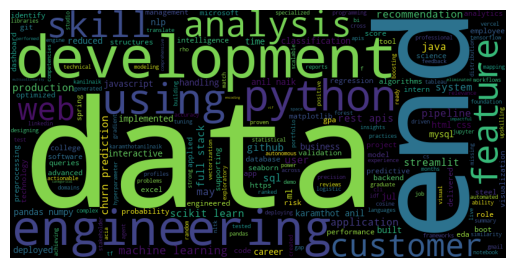

In [ ]:
!pip install Pillow==9.5.0
!pip install wordcloud --upgrade
from wordcloud import WordCloud

wc = WordCloud(width=800,height=400).generate(clean_text)

plt.imshow(wc)

plt.axis("off")

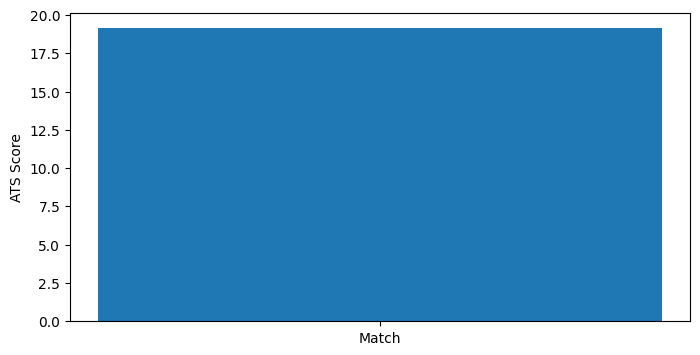

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(["Match"],[score*100])

plt.ylabel("ATS Score")

plt.show()